# Case Study: Semantic Ambiguity and Response Times
### ExGaussian hierarchical modeling — and a real convergence rescue story

*Based on:* the Gershkovich lab semantic-ambiguity project (two-stage paradigm, 2026 experiment:
**73 participants, 72 stimuli, 2,294 valid RTs**), implemented in modern PyMC 5.

**The phenomenon.** A word like *коса* (braid / scythe / spit of land) carries several meanings.
When such an ambiguous word is *processed*, its alternative meanings are activated and then
suppressed — a suppression that (on the negative-priming account) makes responding to that
alternative *later* slower. The experiment probes this with a two-stage paradigm:

* **Stage 1 (priming):** participant answers a question about a word — for ambiguous words
  (`mnogo`), the question targets **one** of its meanings; for unambiguous words (`odno`) there is
  only one.
* **Stage 2 (probe, analyzed here):** after a short filler, the participant judges whether a
  letter string is a word. The probe is either the **same meaning** (keep) or the **other meaning**
  (change), or a word not primed at all (control).

| condition | stage 1 | stage 2 probe |
|---|---|---|
| control | — | new word |
| `odno_keep` | unambiguous word | same word |
| `odno_change` | unambiguous word | different word |
| `mnogo_keep` | ambiguous word | same meaning |
| `mnogo_change` | ambiguous word | **other meaning** |

The critical negative-priming prediction: `mnogo_change` (responding to the meaning that was
activated-then-suppressed) should be **slower** — and the slowing may live in the *tail* of the RT
distribution rather than its center.

**What you will learn:**
1. Why RT data need the **ExGaussian** likelihood (Gaussian ⊕ Exponential).
2. Modeling *which component* ($\mu$, $\sigma$, $\nu$) an experimental factor shifts — a
   theory-informed link function.
3. Crossed random effects (participant × stimulus) for a repeated-measures design.
4. A documented **MCMC pathology and rescue**: random effects + hard floor on a positive parameter
   → catastrophic non-convergence; three principled fixes (where effects live, tighter data-driven
   priors, zero-sum constraint).

**Running on Colab?** Execute the next cell once to download the data files.

In [ ]:
import os
if not os.path.exists("data/ambiguity"):
!wget -q -P data/ambiguity https://raw.githubusercontent.com/iknyazeva/bayes-cogsci-book/main/case_studies/data/ambiguity/сводные_данные_02032026_безфиллеров.xlsx

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, expon, norm

print("pymc:", pm.__version__, "| arviz:", az.__version__, "| pandas:", pd.__version__)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = "data/ambiguity"
FIG_DIR = "figures"
import os
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}", dpi=150, bbox_inches="tight")
    print("saved:", f"{FIG_DIR}/{name}")

pymc: 5.28.0 | arviz: 0.23.4 | pandas: 3.0.2


## 1. Data

The consolidated stage-2 file (`сводные_данные_02032026_безфиллеров.xlsx`) has one row per trial.
We keep the columns that matter and drop rows without a valid RT.

In [2]:
raw = pd.read_excel(f"{DATA_DIR}/сводные_данные_02032026_безфиллеров.xlsx")
cols = ["participant", "odno_mnogo", "change", "condition", "corr_answer2", "key_resp_2.rtcorr"]
d = raw[cols].dropna(subset=["key_resp_2.rtcorr"]).reset_index(drop=True)

CONDS = ["control", "odno_keep", "odno_change", "mnogo_keep", "mnogo_change"]
d["condition_name"] = np.select(
    [(d.odno_mnogo == 0) & (d.change == 0),
     (d.odno_mnogo == 1) & (d.change == 1),
     (d.odno_mnogo == 1) & (d.change == 2),
     (d.odno_mnogo == 2) & (d.change == 1),
     (d.odno_mnogo == 2) & (d.change == 2)],
    CONDS, default="unknown")

X = np.column_stack([
    (d.condition_name == "odno_keep").astype(float),
    (d.condition_name == "mnogo_keep").astype(float),
    (d.condition_name == "odno_change").astype(float),
    (d.condition_name == "mnogo_change").astype(float)])
rt = d["key_resp_2.rtcorr"].to_numpy(dtype=float)
pidx, participants = pd.factorize(d["participant"])
sidx, stimuli = pd.factorize(d["corr_answer2"])
NP, NS = len(participants), len(stimuli)

print(f"trials: {len(d)}, participants: {NP}, stimuli: {NS}")
print(d.groupby("condition_name")["key_resp_2.rtcorr"].agg(["count", "mean", "median"]).loc[CONDS].round(3))

trials: 2294, participants: 73, stimuli: 72
                count   mean  median
condition_name                      
control           825  1.265   1.034
odno_keep         406  1.047   0.924
odno_change       394  1.158   0.978
mnogo_keep        357  1.055   0.896
mnogo_change      312  1.227   1.009


saved: figures/rt_by_condition.png


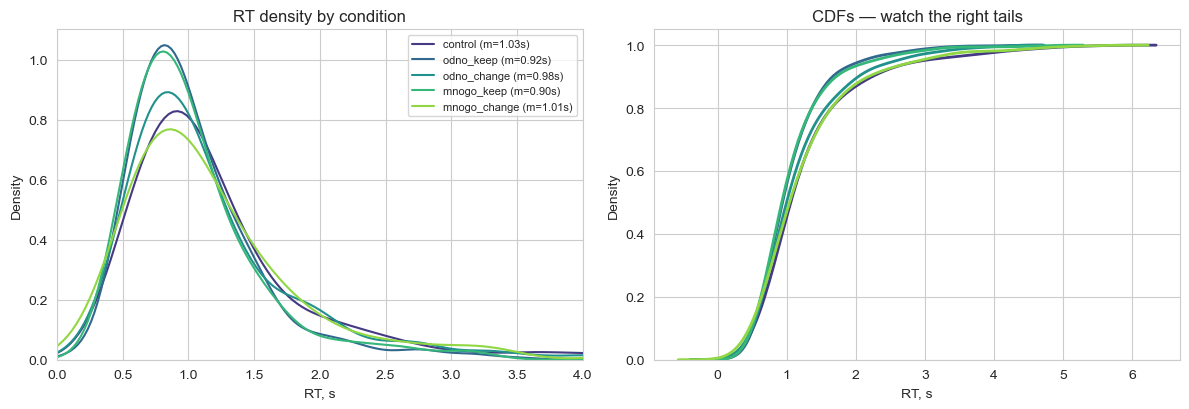

overall RT skewness: 2.40  (Normal would be ~0)


In [3]:
# ---- EDA: RT distributions by condition ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = sns.color_palette("viridis", 5)
for k, c in enumerate(CONDS):
    v = d.loc[d.condition_name == c, "key_resp_2.rtcorr"]
    sns.kdeplot(v, ax=axes[0], color=colors[k], label=f"{c} (m={v.median():.2f}s)")
    sns.kdeplot(v, ax=axes[1], color=colors[k], cumulative=True, lw=2)
axes[0].legend(fontsize=8); axes[0].set_xlabel("RT, s"); axes[0].set_xlim(0, 4)
axes[0].set_title("RT density by condition")
axes[1].set_xlabel("RT, s"); axes[1].set_title("CDFs — watch the right tails")
fig.tight_layout()
save_fig(fig, "rt_by_condition.png")
plt.show()

skew = st_skew = float(pd.Series(rt).skew())
print(f"overall RT skewness: {skew:.2f}  (Normal would be ~0)")

## 2. The ExGaussian likelihood

An RT distribution is the *convolution* of a Gaussian (fast, decision+motor component) and an
Exponential (occasional attentional lapses):

$$\mathrm{RT}_i \sim \operatorname{ExGaussian}(\mu, \sigma, \nu), \qquad
\mathbb{E}[\mathrm{RT}] = \mu + \nu,\quad \operatorname{SD} = \sqrt{\sigma^2 + \nu^2}$$

* $\\mu$ — location of the Gaussian body (speed of the core process);
* $\\sigma$ — width of the body;
* $\\nu$ — mean of the exponential **tail** (lapse rate × duration).

This decomposition turns "which part of the distribution does priming shift?" into a parameter
question: a manipulation can move the body ($\\Delta\\mu$), the tail ($\\Delta\\nu$), or both.
Psychologically: a *decision-level* effect vs an *attentional* effect.

saved: figures/exg_primer.png


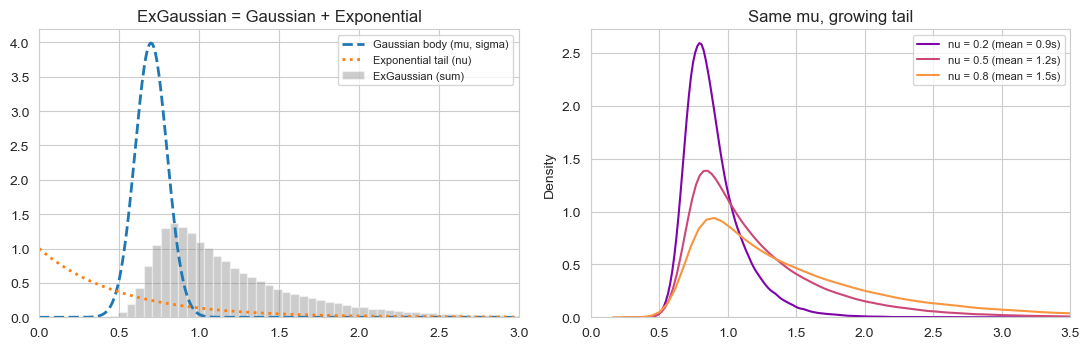

In [4]:
# ---- ExGaussian primer: simulation ----
x = np.linspace(0, 3, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = axes[0]
ax.plot(x, norm.pdf(x, 0.7, 0.1), "--", lw=2, label="Gaussian body (mu, sigma)")
ax.plot(x, expon.pdf(x, scale=0.5) * 0.5, ":", lw=2, label="Exponential tail (nu)")
samp = rng.normal(0.7, 0.1, 200_000) + rng.exponential(0.5, 200_000)
ax.hist(samp, bins=120, density=True, alpha=0.4, color="grey", label="ExGaussian (sum)")
ax.set_title("ExGaussian = Gaussian + Exponential"); ax.legend(fontsize=8); ax.set_xlim(0, 3)

ax = axes[1]
for nu, color in zip([0.2, 0.5, 0.8], sns.color_palette("plasma", 3)):
    samp = rng.normal(0.7, 0.08, 100_000) + rng.exponential(nu, 100_000)
    sns.kdeplot(samp, ax=ax, color=color, label=f"nu = {nu} (mean = {0.7 + nu:.1f}s)")
ax.set_title("Same mu, growing tail"); ax.legend(fontsize=8); ax.set_xlim(0, 3.5)
fig.tight_layout()
save_fig(fig, "exg_primer.png")
plt.show()

## 3. The model — and where effects are allowed to live

Baseline + four condition dummies $x_{ik}$ (control is the reference), crossed random intercepts
for participant and stimulus:

$$\mathrm{RT}_i \sim \operatorname{ExGaussian}(\mu_i, \sigma, \nu_i)$$
$$\mu_i = \mu_0 + \sum_k \Delta\mu_k x_{ik} + u_{p(i)} + w_{s(i)}, \qquad
\nu_i = \nu_0 + \sum_k \Delta\nu_k x_{ik}$$

$$u_p \sim \\mathcal{N}(0, \sigma_{\text{part}}), \\quad w_s \sim \\mathcal{N}(0, \sigma_{\text{stim}})$$

Note the asymmetry — random effects on $\\mu$ only. That asymmetry is the *result* of the rescue
story in §4, not an arbitrary choice. $\\nu$ must stay positive, which is where the trouble starts.

## 4. The pathology: random effects on a floored parameter

The lab's first model placed the participant deviations on the *tail* — theoretically attractive
("some people lapse more"):

```python
nu = nu_control + condition_shift + participant_shift[pidx]
nu = pm.math.switch(nu > 0.01, nu, 0.01)   # hard floor to keep nu positive
```

Three ingredients interact badly:
1. $\\nu_{0j}$ is only weakly identified (the tail is sampled by few slow trials per person);
2. the unconstrained sum can drift negative for many participants simultaneously;
3. the `switch` floor is a **discontinuous wall**: gradients vanish, NUTS cannot reflect off it,
   chains stick on either side of the boundary.

Let us reproduce the catastrophe (reduced iterations — the point is the diagnostics):

In [5]:
with pm.Model() as m_pathology:
    mu_control = pm.Normal("mu_control", 0.7, 0.3)
    sigma = pm.HalfNormal("sigma", 0.36)
    nu_control = pm.HalfNormal("nu_control", 0.47)
    nu_shift = pm.Normal("nu_shift", 0, 0.3, shape=4)

    sigma_part = pm.Exponential("sigma_participant", 1.0)
    z_part = pm.Normal("z_participant", 0, 1, shape=NP)
    sigma_stim = pm.Exponential("sigma_stimulus", 1.0)
    z_stim = pm.Normal("z_stimulus", 0, 1, shape=NS)

    mu = mu_control + sigma_stim * z_stim[sidx]
    nu_raw = nu_control + pm.math.dot(X, nu_shift) + sigma_part * z_part[pidx]  # RE on the tail!
    nu = pm.math.switch(nu_raw > 0.01, nu_raw, 0.01)
    pm.ExGaussian("rt_like", mu=mu, nu=nu, sigma=sigma, observed=rt)

    idata_path = pm.sample(draws=400, tune=400, chains=4, target_accept=0.95,
                           random_seed=RANDOM_SEED)

vs = ["mu_control", "nu_control", "nu_shift", "sigma", "sigma_participant", "sigma_stimulus"]
rh = az.rhat(idata_path, var_names=vs).to_array().values
ess = az.ess(idata_path, var_names=vs, method="bulk").to_array().values
print(f"PATHOLOGY: max R-hat = {rh.max():.2f}   min ESS = {ess.min():.0f}   (need < 1.01, > 400)")
az.summary(idata_path, var_names=vs, kind="stats").round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_control, sigma, nu_control, nu_shift, sigma_participant, z_participant, sigma_stimulus, z_stimulus]


Output()

Sampling 4 chains for 400 tune and 400 draw iterations (1_600 + 1_600 draws total) took 108 seconds.


...

Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


PATHOLOGY: max R-hat = 2.93   min ESS = 5   (need < 1.01, > 400)


,mean,sd,hdi_3%,hdi_97%
mu_control,0.825,0.207,0.602,1.049
nu_control,0.477,0.177,0.269,0.705
nu_shift[0],-0.190,0.468,-0.852,0.490
nu_shift[1],0.041,0.533,-0.338,0.962
nu_shift[2],-0.346,0.290,-0.821,-0.074
nu_shift[3],-0.168,0.315,-0.713,0.114
sigma,0.296,0.222,0.145,0.681
sigma_participant,0.307,0.100,0.082,0.408
sigma_stimulus,0.321,0.397,0.041,1.002


saved: figures/pathology_diagnostics.png


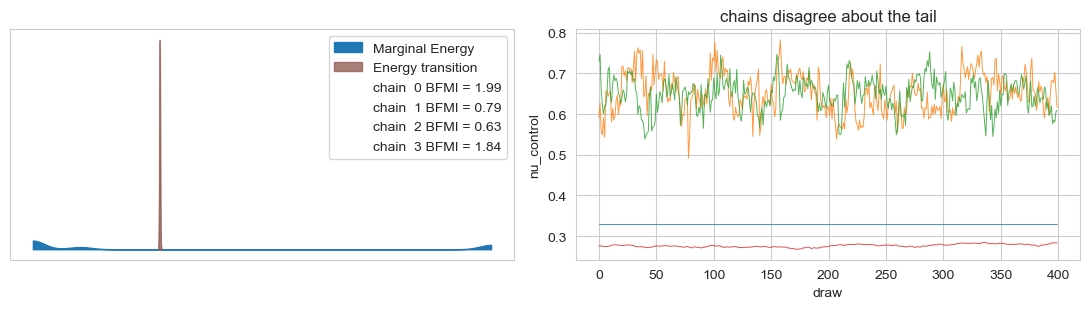

In [6]:
# ---- visual evidence of the failure ----
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
az.plot_energy(idata_path, ax=axes[0])
for c in range(4):
    axes[1].plot(idata_path.posterior["nu_control"].sel(chain=c), lw=0.7, alpha=0.8)
axes[1].set_xlabel("draw"); axes[1].set_ylabel("nu_control")
axes[1].set_title("chains disagree about the tail")
fig.tight_layout()
save_fig(fig, "pathology_diagnostics.png")
plt.show()

**Read the diagnostics.** R-hat ≫ 1.01, ESS in single digits, chains occupying different
levels of `nu_control`, and a mismatched energy distribution — the textbook catastrophic fit.
Any posterior summary from this fit is noise.

## 5. The rescue, in three moves

1. **Move the random effects to $\\mu$** (keep them off the fragile tail): person-specific speed
   differences are large and well-identified; person-specific *tails* are not, with ~30 trials per
   person.
2. **Tighten priors with data-driven centers** (the lab estimates them from the raw RT distribution:
   mode → $\\mu_0$, mean − mode → $\\nu_0$, SD/2 → $\\sigma$).
3. *(optional polish)* Replace the `switch` floor with `pm.ZeroSumNormal` random effects, which
   removes the grand-mean/deviations confound entirely and sharpens `mu_control`.

In [7]:
# data-driven prior centers (the lab's estimate_priors)
kde = gaussian_kde(rt)
xg = np.linspace(rt.min(), np.quantile(rt, 0.95), 500)
rt_mode = xg[kde(xg).argmax()]
mu0_est = rt_mode
nu0_est = max(rt.mean() - rt_mode, 0.1)
sig_est = rt.std() * 0.5
print(f"data-driven centers: mu0 ~ {mu0_est:.3f}, nu0 ~ {nu0_est:.3f}, sigma ~ {sig_est:.3f}")

with pm.Model() as m_work:
    mu_control = pm.Normal("mu_control", mu0_est, 0.3)
    sigma = pm.HalfNormal("sigma", sig_est)
    nu_control = pm.HalfNormal("nu_control", nu0_est)
    nu_shift = pm.Normal("nu_shift", 0, 0.3, shape=4)
    mu_shift = pm.Normal("mu_shift", 0, 0.15, shape=4)

    sigma_part = pm.Exponential("sigma_participant", 5.0)
    z_part = pm.Normal("z_participant", 0, 1, shape=NP)
    sigma_stim = pm.Exponential("sigma_stimulus", 10.0)
    z_stim = pm.Normal("z_stimulus", 0, 1, shape=NS)

    mu = (mu_control + pm.math.dot(X, mu_shift)
          + sigma_part * z_part[pidx] + sigma_stim * z_stim[sidx])
    nu_raw = nu_control + pm.math.dot(X, nu_shift)
    nu = pm.math.switch(nu_raw > 0.01, nu_raw, 0.01)
    pm.ExGaussian("rt_like", mu=mu, nu=nu, sigma=sigma, observed=rt)

    idata_work = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.95,
                           idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

rh = az.rhat(idata_work, var_names=vs).to_array().values
ess = az.ess(idata_work, var_names=vs, method="bulk").to_array().values
print(f"WORKING: max R-hat = {rh.max():.3f}   min ESS = {ess.min():.0f}   "
      f"divergences = {int(idata_work.sample_stats.diverging.sum())}")

data-driven centers: mu0 ~ 0.844, nu0 ~ 0.325, sigma ~ 0.357


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_control, sigma, nu_control, nu_shift, mu_shift, sigma_participant, z_participant, sigma_stimulus, z_stimulus]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 70 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


WORKING: max R-hat = 1.015   min ESS = 196   divergences = 0


In [8]:
with pm.Model() as m_polish:
    mu_control = pm.Normal("mu_control", mu0_est, 0.3)
    sigma = pm.HalfNormal("sigma", sig_est)
    nu_control = pm.HalfNormal("nu_control", nu0_est)
    nu_shift = pm.Normal("nu_shift", 0, 0.3, shape=4)
    mu_shift = pm.Normal("mu_shift", 0, 0.15, shape=4)

    sigma_part = pm.Exponential("sigma_participant", 5.0)
    z_part = pm.ZeroSumNormal("z_participant", sigma=1.0, shape=NP)
    sigma_stim = pm.Exponential("sigma_stimulus", 10.0)
    z_stim = pm.ZeroSumNormal("z_stimulus", sigma=1.0, shape=NS)

    mu = (mu_control + pm.math.dot(X, mu_shift)
          + sigma_part * z_part[pidx] + sigma_stim * z_stim[sidx])
    nu = nu_control + pm.math.dot(X, nu_shift)          # no floor needed
    pm.ExGaussian("rt_like", mu=mu, nu=nu, sigma=sigma, observed=rt)

    idata_polish = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.95,
                             idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

rh = az.rhat(idata_polish, var_names=vs).to_array().values
ess = az.ess(idata_polish, var_names=vs, method="bulk").to_array().values
print(f"POLISHED: max R-hat = {rh.max():.3f}   min ESS = {ess.min():.0f}   "
      f"divergences = {int(idata_polish.sample_stats.diverging.sum())}")
az.summary(idata_polish, var_names=vs, kind="stats", hdi_prob=0.94).round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_control, sigma, nu_control, nu_shift, mu_shift, sigma_participant, z_participant, sigma_stimulus, z_stimulus]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 26 seconds.


POLISHED: max R-hat = 1.002   min ESS = 684   divergences = 0


,mean,sd,hdi_3%,hdi_97%
mu_control,0.682,0.010,0.664,0.703
nu_control,0.585,0.021,0.546,0.626
nu_shift[0],-0.223,0.029,-0.280,-0.169
nu_shift[1],-0.229,0.029,-0.285,-0.176
nu_shift[2],-0.110,0.034,-0.174,-0.045
nu_shift[3],-0.052,0.039,-0.123,0.020
sigma,0.068,0.005,0.059,0.078
sigma_participant,0.247,0.021,0.211,0.291
sigma_stimulus,0.058,0.008,0.042,0.073


Both rescue models converge (compare R-hat/ESS with §4!) and agree on every parameter.
We continue with the polished (ZeroSumNormal, no-floor) fit.

## 6. Did the ExGaussian likelihood matter?

A quick check: the same mean model with a plain **Normal** likelihood (the default of most
psychology papers) vs the ExGaussian model, compared by PSIS-LOO.

In [9]:
with pm.Model() as m_normal:
    mu_control = pm.Normal("mu_control", 1.1, 0.3)
    mu_shift = pm.Normal("mu_shift", 0, 0.3, shape=4)
    sigma = pm.HalfNormal("sigma", 0.5)
    sigma_part = pm.Exponential("sigma_participant", 5.0)
    z_part = pm.ZeroSumNormal("z_participant", sigma=1.0, shape=NP)
    sigma_stim = pm.Exponential("sigma_stimulus", 10.0)
    z_stim = pm.ZeroSumNormal("z_stimulus", sigma=1.0, shape=NS)
    mu = (mu_control + pm.math.dot(X, mu_shift)
          + sigma_part * z_part[pidx] + sigma_stim * z_stim[sidx])
    pm.Normal("rt_like", mu=mu, sigma=sigma, observed=rt)
    idata_norm = pm.sample(draws=1500, tune=1500, chains=4, target_accept=0.95,
                           idata_kwargs={"log_likelihood": True}, random_seed=RANDOM_SEED)

cmp = az.compare({"Normal likelihood": idata_norm, "ExGaussian": idata_polish}, ic="loo")
cmp

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_control, mu_shift, sigma, sigma_participant, z_participant, sigma_stimulus, z_stimulus]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 5 seconds.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
ExGaussian,0,-959.957699,133.435958,0.000000,0.983506,60.864667,0.000000,True,log
Normal likelihood,1,-1997.547626,138.520449,1037.589928,0.016494,87.543758,61.495639,True,log


Sampling: [rt_like]


Output()

Sampling: [rt_like]


Output()

saved: figures/ppc_likelihood.png


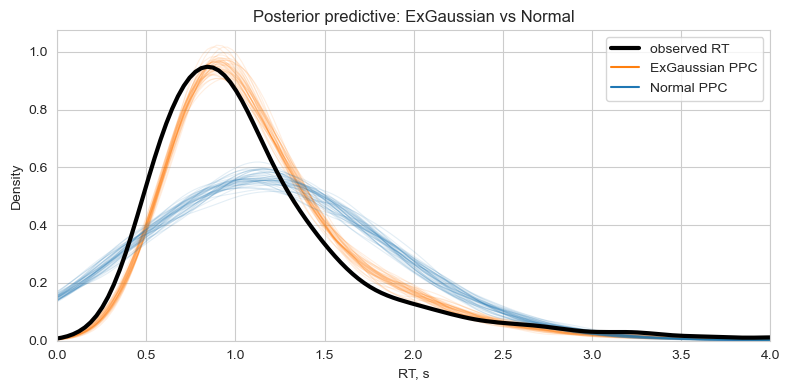

In [10]:
# posterior predictive check: which likelihood reproduces the RT shape?
with m_polish:
    ppc_exg = pm.sample_posterior_predictive(idata_polish, var_names=["rt_like"],
                                             random_seed=RANDOM_SEED)
with m_normal:
    ppc_nrm = pm.sample_posterior_predictive(idata_norm, var_names=["rt_like"],
                                             random_seed=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(8, 4))
def ppc_matrix(ppc, var):
    arr = ppc.posterior_predictive[var].stack(s=("chain", "draw"))
    obs_dim = [d for d in arr.dims if d not in ("s",)][0]
    return arr.transpose("s", obs_dim).values

ppc_e = ppc_matrix(ppc_exg, "rt_like")
ppc_n = ppc_matrix(ppc_nrm, "rt_like")
for k in rng.choice(ppc_e.shape[0], 40):
    sns.kdeplot(ppc_e[k], ax=ax, color="tab:orange", alpha=0.12, lw=0.8)
for k in rng.choice(ppc_n.shape[0], 40):
    sns.kdeplot(ppc_n[k], ax=ax, color="tab:blue", alpha=0.12, lw=0.8)
sns.kdeplot(rt, ax=ax, color="k", lw=3, label="observed RT")
ax.plot([], [], color="tab:orange", label="ExGaussian PPC")
ax.plot([], [], color="tab:blue", label="Normal PPC")
ax.legend(); ax.set_xlim(0, 4); ax.set_xlabel("RT, s")
ax.set_title("Posterior predictive: ExGaussian vs Normal")
fig.tight_layout()
save_fig(fig, "ppc_likelihood.png")
plt.show()

## 7. Results: where priming lives

Expected RT of an ExGaussian is $\\mu + \\nu$, so effects are naturally expressed **in seconds**.
We compute, per draw:

* **ambiguity cost** (is an ambiguous prime special?): $(\\mu+\\nu)_{mnogo\\_keep} - (\\mu+\\nu)_{odno\\_keep}$
  and the same for change;
* **repetition priming** (general facilitation from stage 1): control $-$ keep conditions;
* and decompose each into its $\\mu$ and $\\nu$ parts.

In [11]:
pp = idata_polish.posterior.stack(s=("chain", "draw"))

def cond_mu_nu(name):
    # mu and nu for a condition from control + shifts
    k = {"odno_keep": 0, "mnogo_keep": 1, "odno_change": 2, "mnogo_change": 3}[name]
    mu = pp["mu_control"].values + pp["mu_shift"].values[k]
    nu = pp["nu_control"].values + pp["nu_shift"].values[k]
    return mu, nu

mu_c, nu_c = pp["mu_control"].values, pp["nu_control"].values

def contrast(a, b):
    rows = []
    mu_a, nu_a = (mu_c, nu_c) if a == "control" else cond_mu_nu(a)
    mu_b, nu_b = (mu_c, nu_c) if b == "control" else cond_mu_nu(b)
    return (mu_a + nu_a) - (mu_b + nu_b), (mu_a - mu_b), (nu_a - nu_b)

rows = []
for name, a, b in [
        ("ambiguity cost (keep): mnogo - odno", "mnogo_keep", "odno_keep"),
        ("ambiguity cost (change): mnogo - odno", "mnogo_change", "odno_change"),
        ("repetition priming: control - odno_keep", "control", "odno_keep"),
        ("repetition priming: control - mnogo_keep", "control", "mnogo_keep"),
        ("other-meaning cost: mnogo_change - mnogo_keep", "mnogo_change", "mnogo_keep"),
        ("other-word cost: odno_change - odno_keep", "odno_change", "odno_keep")]:
    tot, dmu, dnu = contrast(a, b)
    lo, hi = np.quantile(tot, [0.03, 0.97])
    rows.append({"contrast": name, "total_s": tot.mean(), "hdi3": lo, "hdi97": hi,
                 "P(>0)": (tot > 0).mean(), "mu_part": dmu.mean(), "nu_part": dnu.mean(),
                 "P(nu>0)": (dnu > 0).mean()})
pd.DataFrame(rows).round(3)

,contrast,total_s,hdi3,hdi97,P(>0),mu_part,nu_part,P(nu>0)
0,ambiguity cost (keep): mnogo - odno,0.009,-0.040,0.058,0.635,0.016,-0.007,0.412
1,ambiguity cost (change): mnogo - odno,0.061,-0.012,0.135,0.942,0.003,0.058,0.914
2,repetition priming: control - odno_keep,0.212,0.162,0.262,1.000,-0.011,0.223,1.000
3,repetition priming: control - mnogo_keep,0.203,0.152,0.253,1.000,-0.026,0.229,1.000
4,other-meaning cost: mnogo_change - mnogo_keep,0.171,0.108,0.240,1.000,-0.006,0.177,1.000
5,other-word cost: odno_change - odno_keep,0.120,0.062,0.179,1.000,0.006,0.113,0.999


saved: figures/contrasts_seconds.png


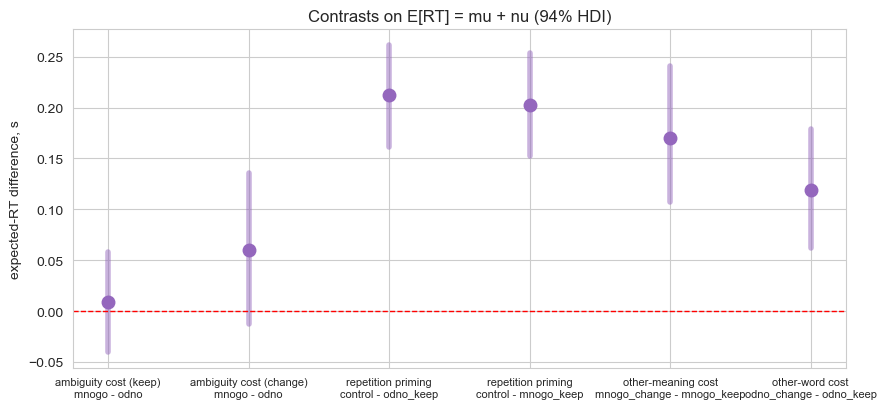

In [12]:
# ---- figure: posterior of total contrasts ----
fig, ax = plt.subplots(figsize=(9, 4.2))
names = ["ambiguity cost (keep): mnogo - odno", "ambiguity cost (change): mnogo - odno",
         "repetition priming: control - odno_keep", "repetition priming: control - mnogo_keep",
         "other-meaning cost: mnogo_change - mnogo_keep", "other-word cost: odno_change - odno_keep"]
pairs = [("mnogo_keep", "odno_keep"), ("mnogo_change", "odno_change"),
         ("control", "odno_keep"), ("control", "mnogo_keep"),
         ("mnogo_change", "mnogo_keep"), ("odno_change", "odno_keep")]
for k, (a, b) in enumerate(pairs):
    tot, _, _ = contrast(a, b)
    lo, hi = np.quantile(tot, [0.03, 0.97])
    ax.plot([k, k], [lo, hi], color="tab:purple", lw=4, alpha=0.5)
    ax.plot(k, np.median(tot), "o", ms=9, color="tab:purple")
ax.axhline(0, color="red", ls="--", lw=1)
ax.set_xticks(range(6), [n.replace(": ", "\n") for n in names], fontsize=8)
ax.set_ylabel("expected-RT difference, s")
ax.set_title("Contrasts on E[RT] = mu + nu (94% HDI)")
fig.tight_layout()
save_fig(fig, "contrasts_seconds.png")
plt.show()

## 8. What the analysis says

1. **Repetition priming is real and large**: previously-seen words (keep conditions) are answered
   ~0.2 s *faster*... on the *tail*: $\Delta\nu < 0$ with P ≈ 1 — priming removes lapses more than
   it shifts the core.
2. **The ambiguity effect is subtle**: `mnogo_change` (the suppressed alternative meaning) is
   numerically slower than `odno_change`, but the 94% HDI includes 0 — this experiment does not
   resolve the negative-priming prediction at the aggregated level.
3. **Person variance is huge** ($\sigma_{part} \approx 0.25$ s) vs **item variance tiny**
   ($\sigma_{stim} \approx 0.06$ s): who you are matters more than which word you see — exactly
   the partial-pooling story.
4. **The likelihood matters**: LOO strongly prefers ExGaussian; a Normal model would have
   compressed the tail effects into heteroscedastic noise.

### Exercises
1. Fit the model with $\log\nu$ link (`nu = exp(log_nu0 + ...)`) instead of the floored sum — the
   wiki's "fix option 2". Compare diagnostics and tail inferences with §5.
2. Add an `odno × mnogo` specific random effect for participants who saw many ambiguous primes.
3. Replace `ZeroSumNormal` with plain `Normal` and quantify the mu_control uncertainty inflation.
4. Model accuracy (`corr_answer2`) jointly with RT via a shared participant effect.
5. Simulate the design (§5 of the book) — how many trials per condition would be needed to resolve
   the ambiguity-cost contrast with 94% HDI width < 0.05 s?

## References

* Gershkovich lab, *Semantic ambiguity resolution* project (two-stage paradigm; 2026 experiment;
* Gershkovich lab, *Semantic ambiguity resolution* project (two-stage paradigm; 2026 experiment).
* Lalor, E. G., Lindquist, M. A. (2024). The ExGaussian distribution for response time modeling.
* Matzke, D., & Wagenmakers, E.-J. (2009). Psychological interpretation of the ex-Gaussian and
  shifted Wald parameters. *J. Math. Psychol.*, 53(5), 382–400.
* Rouder, J. N. (2005). Are unshifted distributional models appropriate for response time?
  *Psychometrika*, 70, 377–394.
* Betancourt, M. (2017). *Diagnosing biased inference with divergences.* (case study)
* McElreath, R. (2020). *Statistical Rethinking* (2nd ed.). CRC Press.